In [1]:
import os
import sys
from collections import Counter
# Add project path
notebook_path = os.getcwd()
sys.path.insert(0, os.path.dirname(notebook_path))

# current_file = os.path.abspath(__file__)
# grandparent_dir = os.path.dirname(os.path.dirname(current_file))
# sys.path.insert(0, grandparent_dir)


import numpy as np
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.data import Data
from torch_geometric.typing import Adj
import itertools
from torch_geometric.utils import (
    degree,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    from_networkx,
    to_networkx,
    train_test_split_edges,
    to_undirected
)
from torch_geometric.data import Data
from syn_real.custom_wl import (get_graph_orbits,
                                run_wl_test_and_group_nodes)
from syn_real.plotting import plot_graph_with_orbits
from syn_real.measure import (hash_links_by_orbit, 
                              compute_automorphism_metrics,
                              count_automorphic_edges
                            )
from syn_real.auto_operation import (create_disjoint_graph,
                            add_random_edges)
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.data import Data
import pandas as pd 

/home/ka/ka_aifb/ka_cc7738/miniconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=4, node_idx=0, visualize=True):
    """
    Load a dataset and extract a k-hop subgraph around a given node.
    
    Args:
        dataset_name (str): e.g. "Cora", "Citeseer", "PubMed"
        num_hops (int): Number of hops to include in the subgraph
        node_idx (int): Center node to extract from
        visualize (bool): If True, visualize the subgraph

    Returns:
        Data: PyG Data object of the subgraph
    """
    # Load dataset
    dataset = Planetoid(root=f'{dataset_name}', name=dataset_name)
    data = dataset[0]

    # Extract k-hop subgraph
    subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True,
        num_nodes=data.num_nodes
    )

    # Create subgraph Data object
    sub_x = data.x[subset]
    sub_y = data.y[subset]
    sub_data = Data(x=sub_x, edge_index=sub_edge_index, y=sub_y)

    # Optional visualization
    if visualize:
        G_sub = to_networkx(sub_data, to_undirected=True)
        plt.figure(figsize=(8, 6))
        nx.draw(G_sub, with_labels=True, node_size=300, node_color='skyblue', edge_color='gray')
        plt.title(f"{num_hops}-Hop Subgraph from Node {node_idx} ({dataset_name})")
        plt.axis('off')
        plt.show()

    return sub_data



def plot_orbit_dist(node_groups):
    node_dist = {}
    for node, label in enumerate(node_groups):
        if label not in node_dist:
            node_dist[label] = []
        node_dist[label].append(node)
        
    group_sizes = np.array([len(group) for group in node_dist.values()])
    

    plt.figure(figsize=(6, 4))
    plt.hist(group_sizes, bins=range(min(group_sizes), max(group_sizes) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Histogram of Orbit Size (Dist of Dist)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()



def plot_orbit(orbits):
    plt.figure(figsize=(6, 4))
    plt.hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Orbit Distribution')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()
    


def plot_combined_orbit_graph(G, pos, orbits, edge_class_counts, custom_labels=None, figsize=(18, 6), cmap='tab20b'):
    """
    Combine three plots into one figure with three subplots:
    1. Graph colored by orbit labels
    2. Orbit distribution histogram
    3. Automorphic edge distribution stem plot

    Parameters:
        G (nx.Graph): The graph to plot.
        pos (dict): Node positions.
        orbits (list or array): Orbit label for each node.
        edge_class_counts (dict): Dictionary of edge class counts.
        custom_labels (dict, optional): Dictionary of node labels.
        figsize (tuple): Figure size.
        cmap (str): Matplotlib colormap for nodes.
    """

    fig, axs = plt.subplots(1, 3, figsize=figsize)

    # 1. Graph with node colors by orbit labels
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=custom_labels,
        node_color=node_colors,
        cmap=cmap,
        node_size=500,
        font_weight='bold',
        edgecolors='black',
        ax=axs[0]
    )
    axs[0].set_title("Graph Colored by Orbit Labels")

    # 2. Orbit distribution histogram
    axs[1].hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    axs[1].set_xlabel('Orbit Label')
    axs[1].set_ylabel('Frequency')
    axs[1].set_title('Orbit Distribution')
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Automorphic edge distribution stem plot
    unique_orbit_seq = sorted(edge_class_counts.values(), reverse=True)
    axs[2].stem(unique_orbit_seq, markerfmt='bo', basefmt=' ')
    axs[2].set_title('Automorphic Edge Distribution')
    axs[2].set_xlabel("Automorphism Edge Classes")
    axs[2].set_ylabel("Frequency")
    axs[2].grid(True, linestyle='--', alpha=0.7)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()
    plt.savefig('example.pdf')

    
def analyze_automorphisms(data, G):

    _, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, num_nodes=data.num_nodes, num_iterations=100)
    orbits, num_orbit = get_graph_orbits(G)
    # print(f"Number of orbits: {num_orbit}")

    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"

    non_edge = count_automorphic_edges(G, orbits)
    
    # metrics, num_nodes, group_sizes = compute_automorphism_metrics(orbits, G.number_of_nodes())
    
    # plot_orbit_dist(orbits)
    # plot_graph_with_orbits(G, 
    #                        None, 
    #                        orbits, 
    #                        custom_labels=custom_labels, 
    #                        figsize=(8, 6), cmap='tab20b')
    # plot_orbit(orbits)
    edge_class_counts, _ = hash_links_by_orbit(G, orbits)
    # from syn_real.plotting import plot_unique_edge_class
    # plot_unique_edge_class(edge_class_counts)

    plot_combined_orbit_graph(G, None, orbits, edge_class_counts, custom_labels=custom_labels)
    return non_edge

In [3]:

def add_isolated_node_for_node(data, node_idx, copy_feature=True):
    """
    Add one isolated node to the graph, associated with a given node (no edges).
    
    Args:
        data (Data): Original PyG data object.
        node_idx (int): Index of the node to associate the new isolated node with.
        copy_feature (bool): If True, copy the feature of the given node; else zero vector.
    
    Returns:
        Data: New PyG data object with an isolated node added.
    """
    assert node_idx < data.num_nodes, "node_idx out of range"

    # 1. Add new node feature
    F = data.x.size(1)
    if copy_feature:
        new_feat = data.x[node_idx].unsqueeze(0)  # shape: [1, F]
    else:
        new_feat = torch.zeros((1, F))

    new_x = torch.cat([data.x, new_feat], dim=0)

    # 2. Add dummy label for new node if labels exist
    if data.y is not None:
        new_y = torch.cat([data.y, torch.tensor([-1], dtype=data.y.dtype)])
    else:
        new_y = None

    # 3. edge_index stays unchanged (new node is isolated)
    new_data = Data(x=new_x, edge_index=data.edge_index, y=new_y)

    # 4. Track association to original node
    new_data.original_node_ids = torch.cat([
        getattr(data, 'original_node_ids', torch.arange(data.num_nodes)),
        torch.tensor([node_idx])
    ])

    return new_data

In [4]:
import torch
from torch_geometric.data import Data

def add_node_connected_to_node(data, node_idx, copy_feature=True, undirected=True):
    """
    Add one new node to the graph and connect it with an edge to the given node.
    
    Args:
        data (Data): Original PyG data object.
        node_idx (int): Index of the node to connect the new node to.
        copy_feature (bool): If True, copy the feature of the given node; else zero vector.
        undirected (bool): If True, add bidirectional edge.
    
    Returns:
        Data: New PyG data object with a connected node added.
    """
    assert node_idx < data.num_nodes, "node_idx out of range"

    F = data.x.size(1)
    if copy_feature:
        new_feat = data.x[node_idx].unsqueeze(0)  
    else:
        new_feat = torch.zeros((1, F))
    
    new_x = torch.cat([data.x, new_feat], dim=0)
    if data.y is not None:
        new_y = torch.cat([data.y, torch.tensor([-1], dtype=data.y.dtype)])
    else:
        new_y = None

    new_node_id = data.num_nodes
    edges = [[new_node_id, node_idx]]
    if undirected:
        edges.append([node_idx, new_node_id])

    edge_add = torch.tensor(edges, dtype=torch.long).t()  
    new_edge_index = torch.cat([data.edge_index, edge_add], dim=1)

    new_data = Data(x=new_x, edge_index=new_edge_index, y=new_y)
    return new_data

def perturb_disjoint(graph_data, inter_ratio, intra_ratio, total_edges):
    """
    Run the experiment with the given parameters.
    
    Parameters:
        graph_data (torch_geometric.data.Data): The input graph data.
        args (argparse.Namespace): Arguments containing dataset name.
        inter_ratio (float): Fraction of edges to add between the two graph copies.
        intra_ratio (float): Fraction of edges to add within each graph copy.
        total_edges (int): Total number of random edges to add.
    """
    # Add random edges to the graph
    if inter_ratio != 0 and intra_ratio != 0 and total_edges != 0:
        updated_graph_data = add_random_edges(graph_data, 
                                              inter_ratio=inter_ratio, 
                                              intra_ratio=intra_ratio, 
                                              total_edges=total_edges)
    else:
        updated_graph_data = graph_data

    G = to_networkx(updated_graph_data, to_undirected=True)
    num_nodes = updated_graph_data.num_nodes

    node_groups, node_labels, new_labels = run_wl_test_and_group_nodes(updated_graph_data.edge_index, num_nodes=num_nodes, num_iterations=30)
    non_edges = count_automorphic_edges(G, node_labels)
    metrics_after, num_nodes, group_sizes = compute_automorphism_metrics(node_groups, num_nodes)
    df = pd.DataFrame([metrics_after])
    print(df)
    
    print(f"Finished with inter_ratio={inter_ratio}, intra_ratio={intra_ratio}, total_edges={total_edges}")
    return updated_graph_data, metrics_after 



import networkx as nx
from torch_geometric.utils import from_networkx
from torch_geometric.data import Data

import random

def attach_star_graph(G_orig: nx.Graph, N: int, ig: int):
    G_combined = G_orig.copy()
    offset = max(G_combined.nodes) + 1 if len(G_combined.nodes) > 0 else 0

    G_star = nx.star_graph(N - 1)
    mapping = {i: i + offset for i in G_star.nodes}
    G_star = nx.relabel_nodes(G_star, mapping)
    center_node_new = mapping[0]

    # Add star to combined graph
    G_combined.add_nodes_from(G_star.nodes(data=True))
    G_combined.add_edges_from(G_star.edges(data=True))

    # Add connecting edge to original graph
    G_combined.add_edge(center_node_new, ig)

    # Track star nodes (including connecting edge)
    star_nodes = set(G_star.nodes)
    star_edges = set(G_star.edges)
    star_edges.add((center_node_new, ig))  # include connection edge

    # Convert to PyG
    data = from_networkx(G_combined)
    return G_combined, data, star_edges



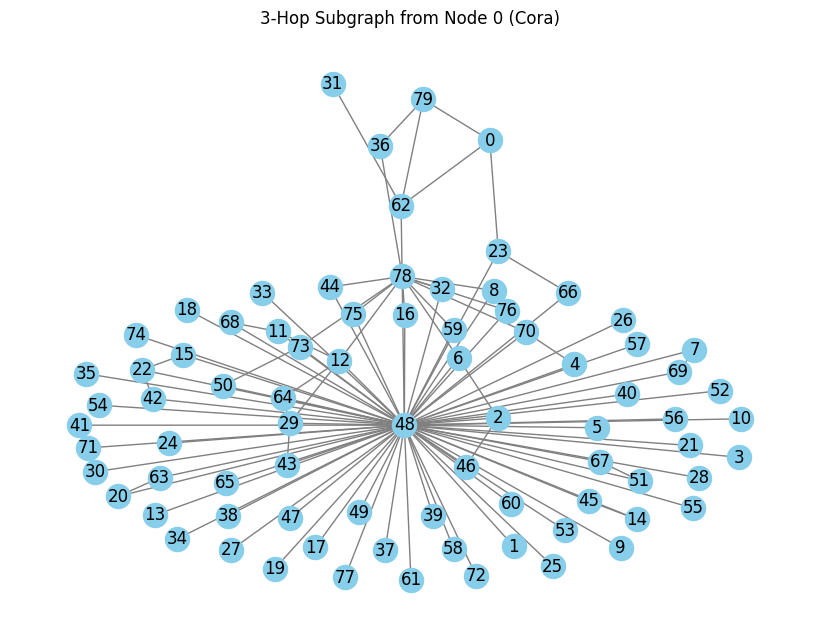

Before:
Num nodes: 80
Num edges: 218
Intra-orbit edges: 1725, Inter-orbit edges: 4314
Non-distinguishable edges: 6039


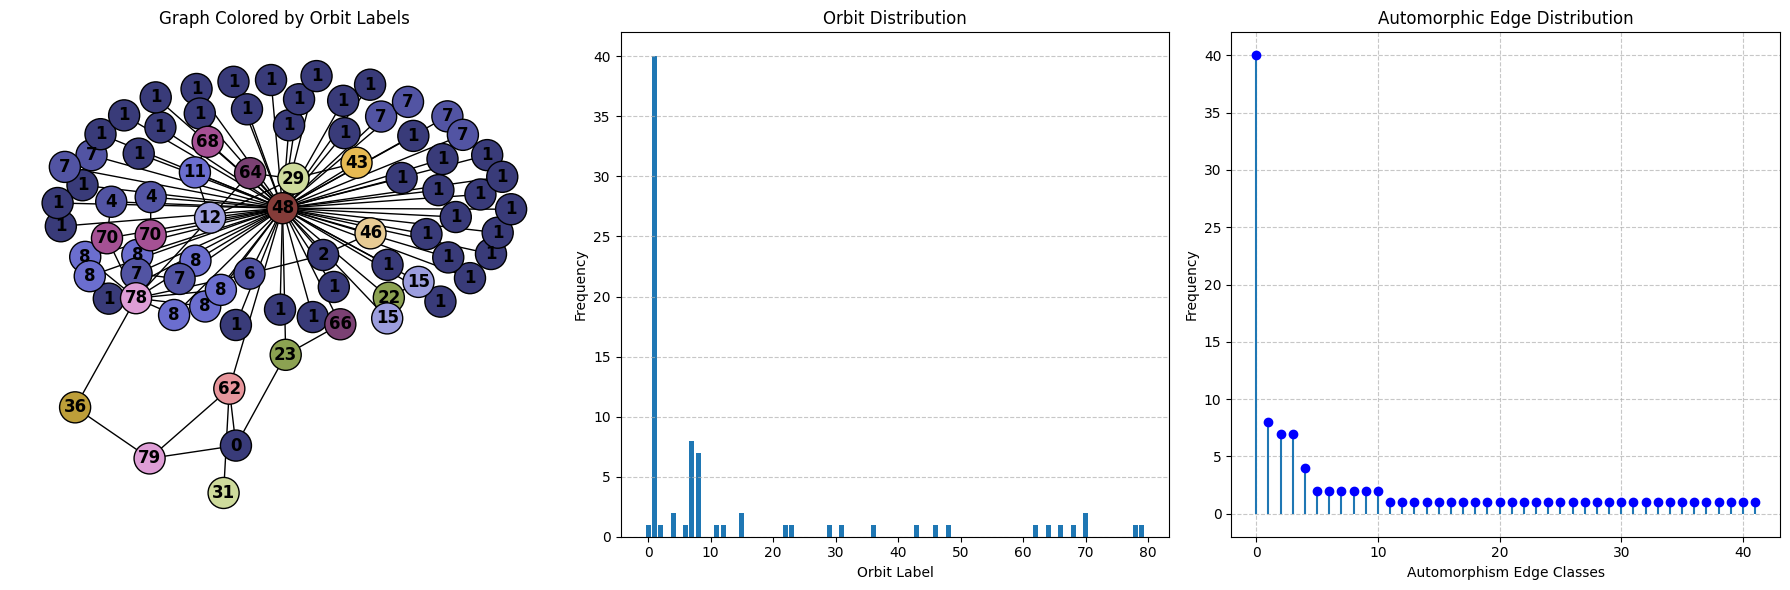

<Figure size 640x480 with 0 Axes>

In [5]:
data = get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=3, node_idx=0, visualize=True)
print("Before:")
print("Num nodes:", data.num_nodes)
print("Num edges:", data.edge_index.size(1))

G = to_networkx(data, to_undirected=True)
analyze_automorphisms(data, G)

ig = 2     
N = 4    



In [7]:
import random 

def remove_random_edges(G: nx.Graph, num_edges: int, protected_edges: set):
    """
    Randomly removes num_edges from G excluding those in protected_edges.
    """
    all_edges = set(G.edges)
    removable_edges = list(all_edges - protected_edges)

    if len(removable_edges) < num_edges:
        raise ValueError("Not enough removable edges to delete.")

    to_remove = random.sample(removable_edges, num_edges)
    G.remove_edges_from(to_remove)
    return G


Intra-orbit edges: 1806, Inter-orbit edges: 5894
Non-distinguishable edges: 7700


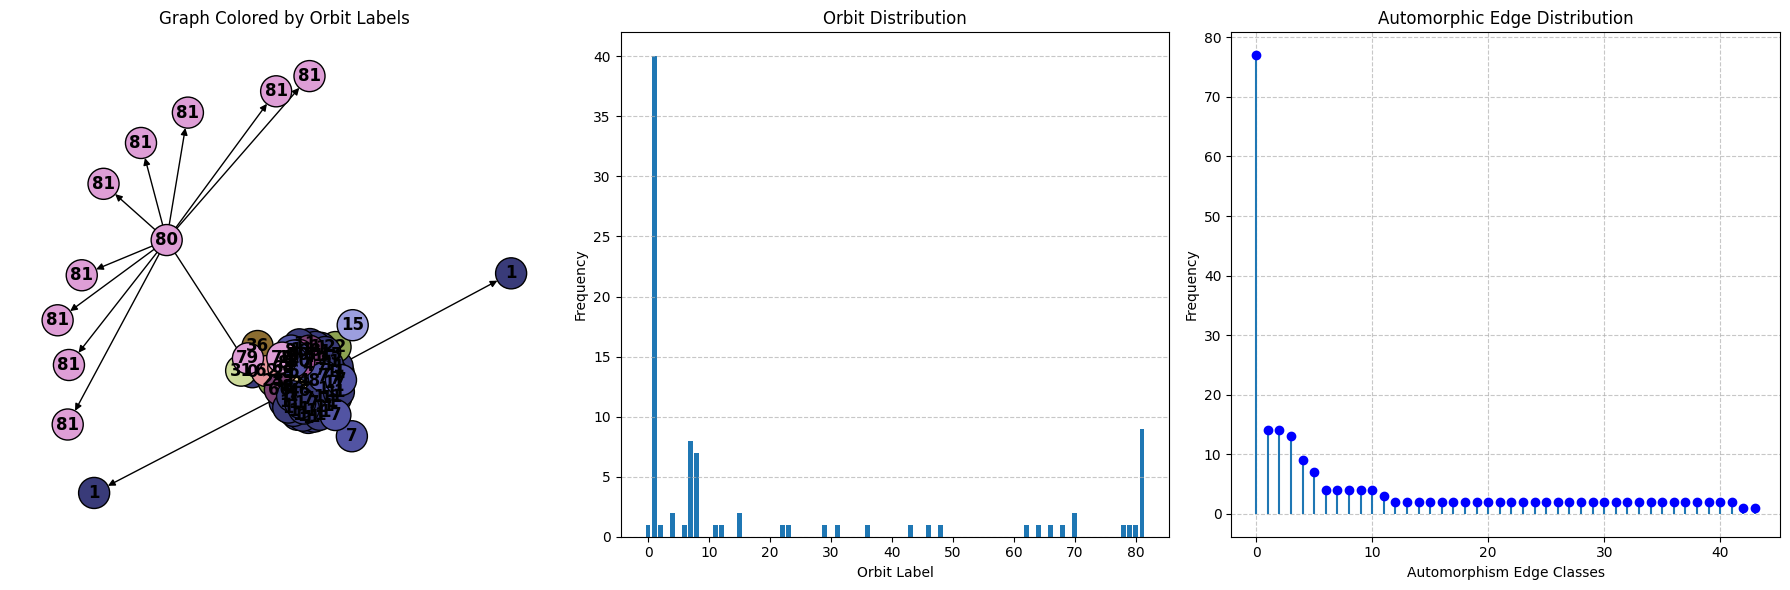

Intra-orbit edges: 1887, Inter-orbit edges: 7672
Non-distinguishable edges: 9559


<Figure size 640x480 with 0 Axes>

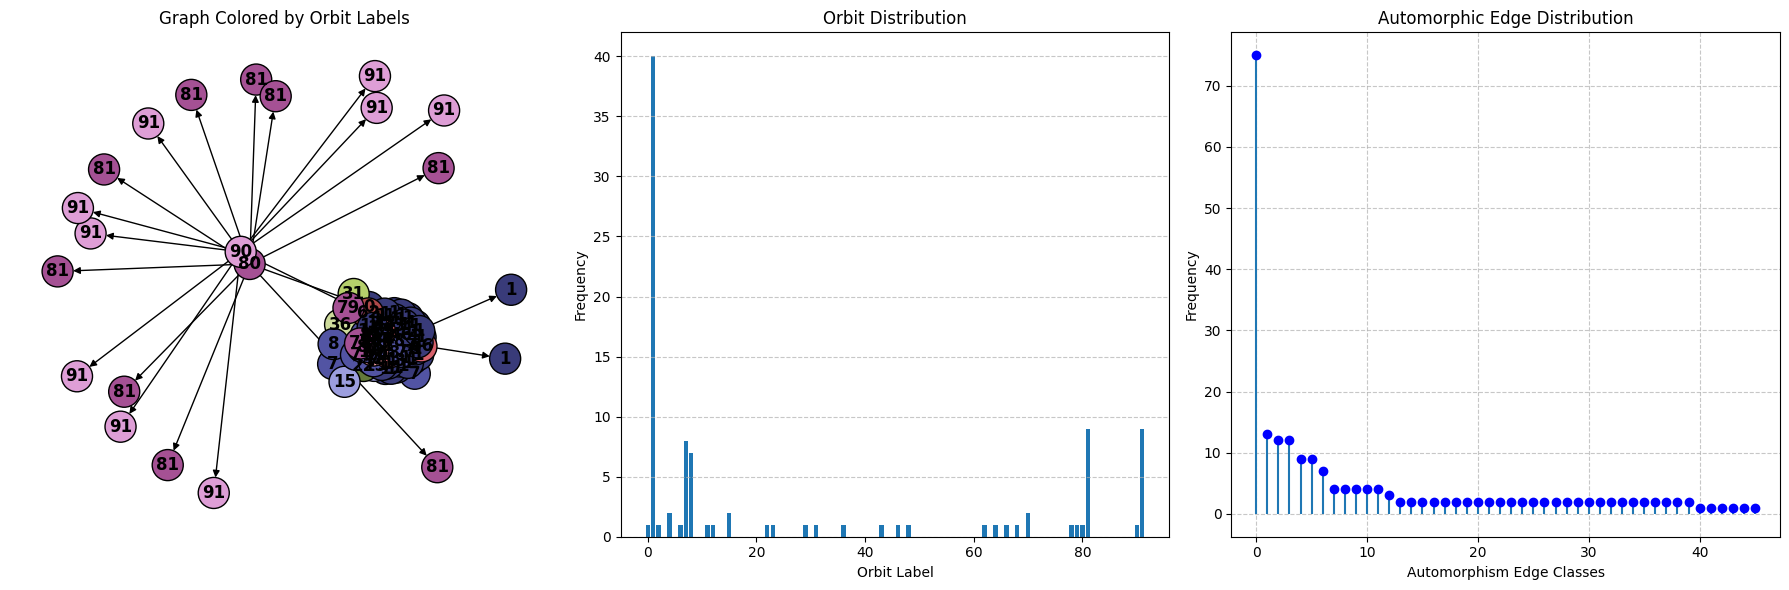

Intra-orbit edges: 1887, Inter-orbit edges: 9852
Non-distinguishable edges: 11739


<Figure size 640x480 with 0 Axes>

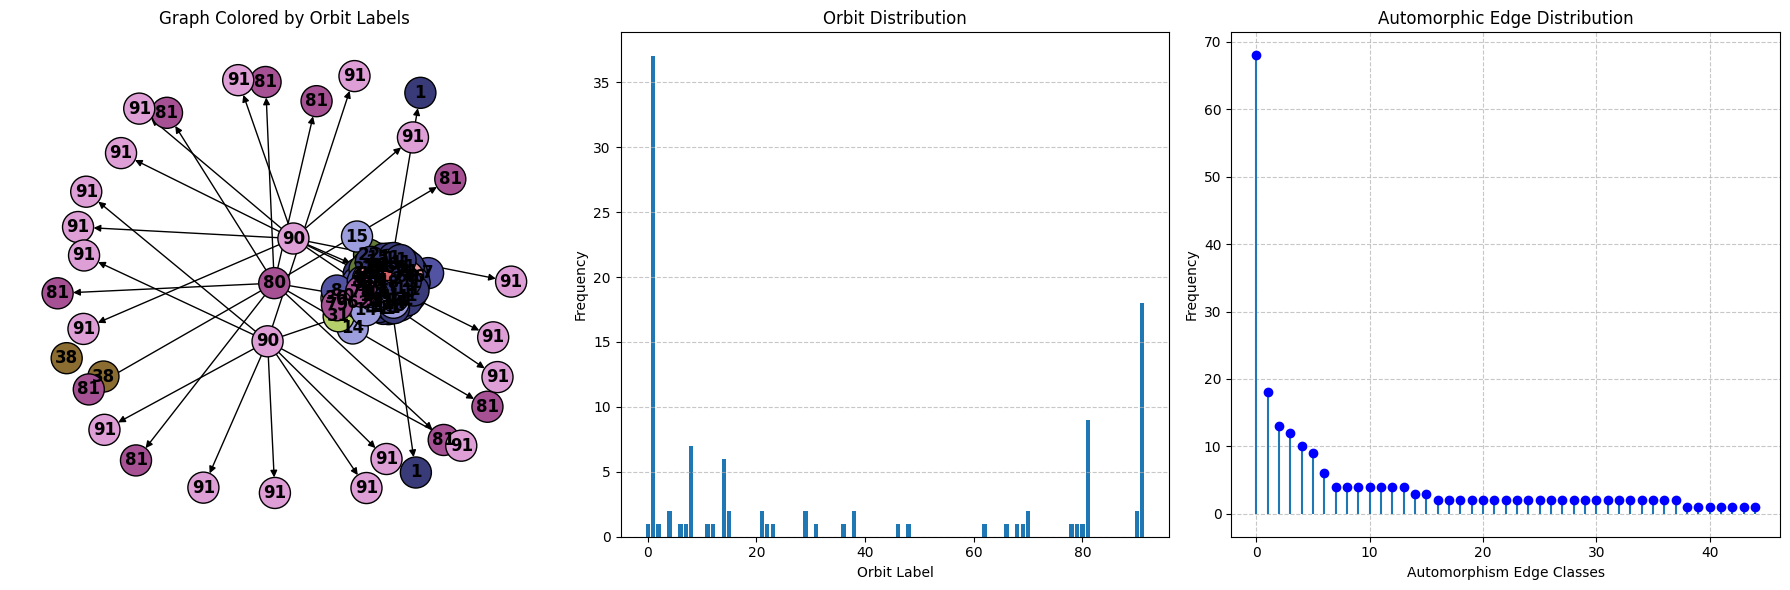

Intra-orbit edges: 1867, Inter-orbit edges: 12092
Non-distinguishable edges: 13959


<Figure size 640x480 with 0 Axes>

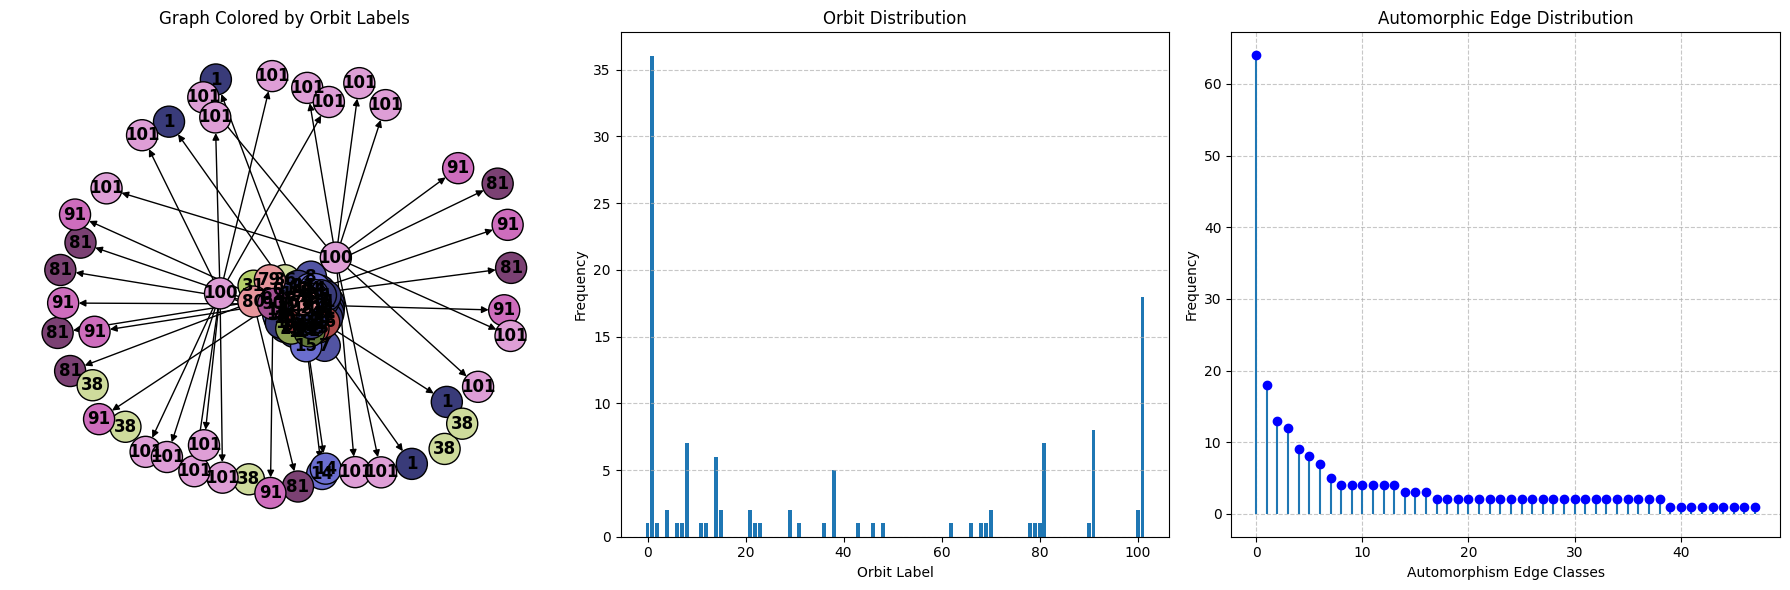

Intra-orbit edges: 1869, Inter-orbit edges: 14502
Non-distinguishable edges: 16371


<Figure size 640x480 with 0 Axes>

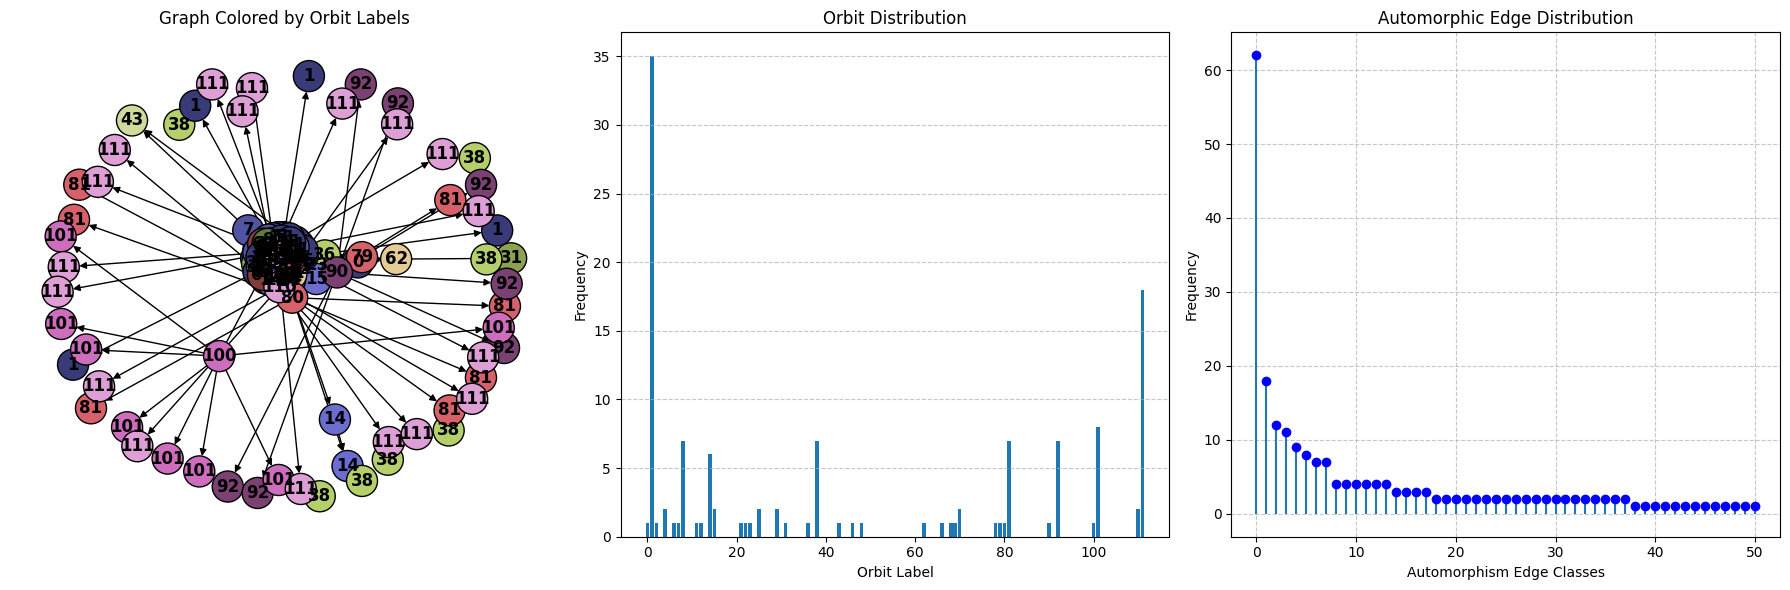

Intra-orbit edges: 1900, Inter-orbit edges: 17124
Non-distinguishable edges: 19024


<Figure size 640x480 with 0 Axes>

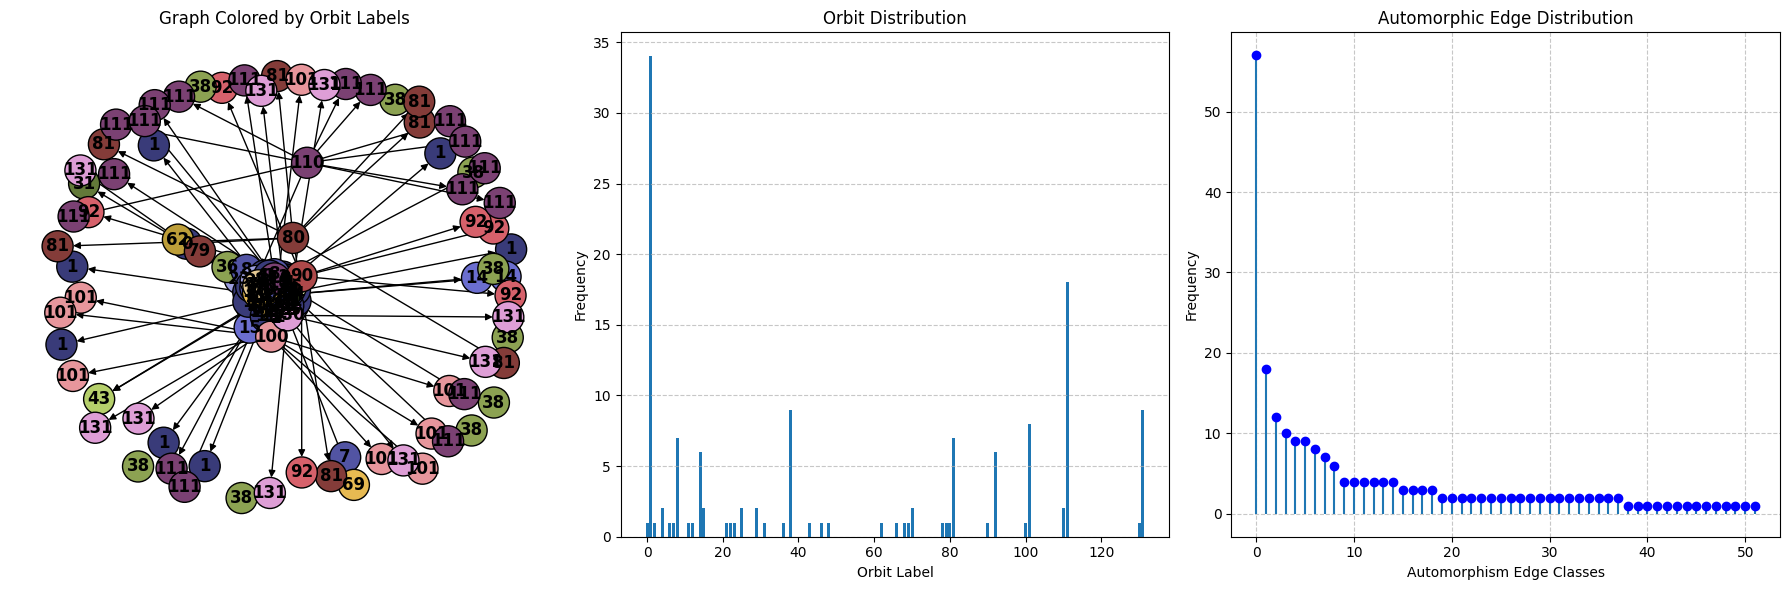

Intra-orbit edges: 2145, Inter-orbit edges: 19826
Non-distinguishable edges: 21971


<Figure size 640x480 with 0 Axes>

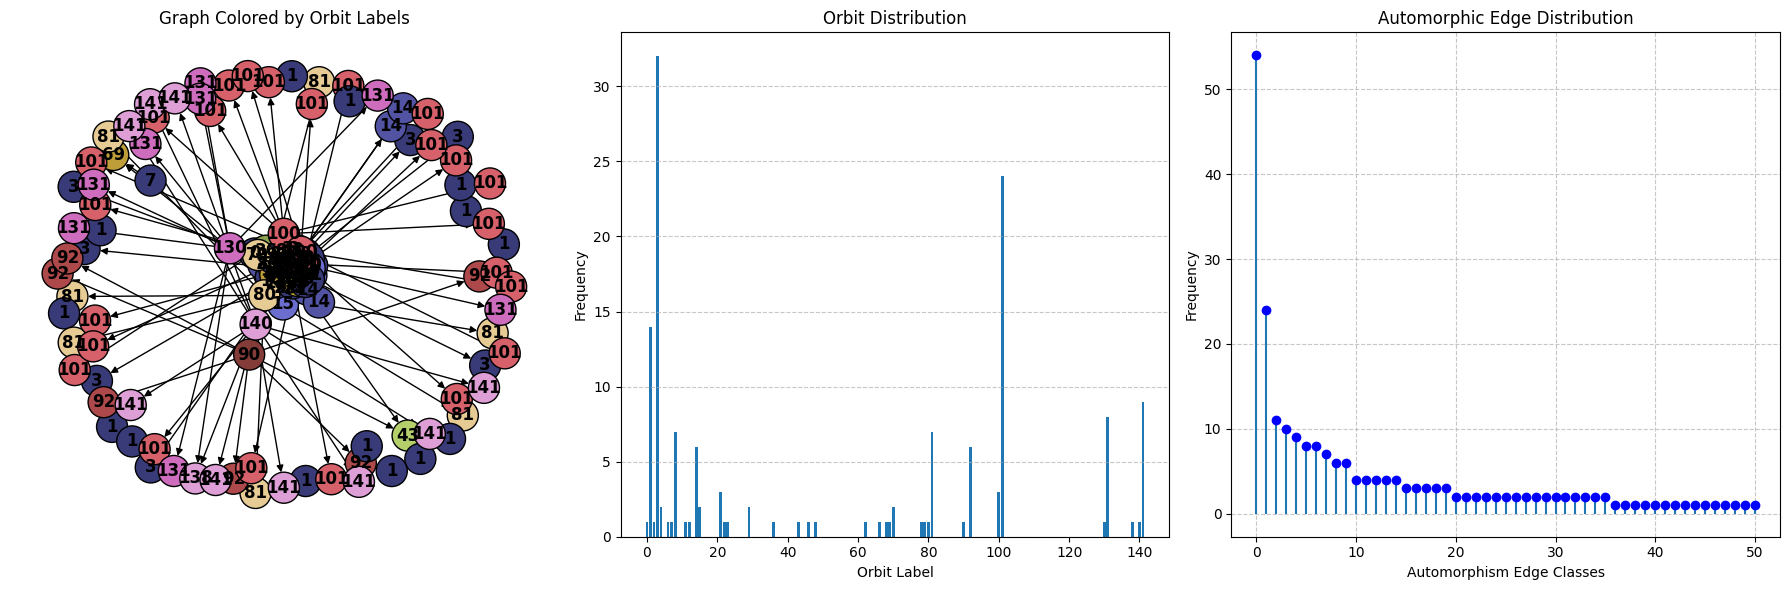

Intra-orbit edges: 1980, Inter-orbit edges: 22944
Non-distinguishable edges: 24924


<Figure size 640x480 with 0 Axes>

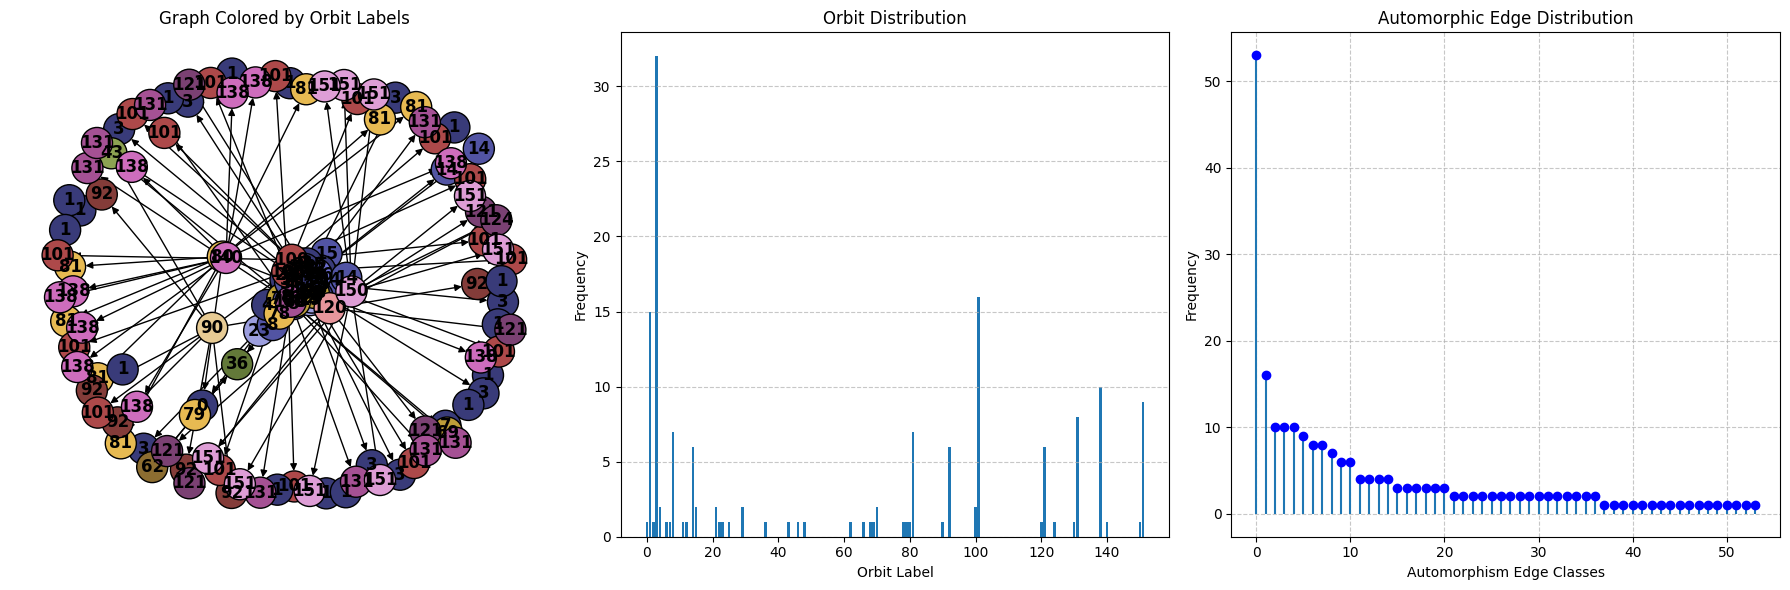

Intra-orbit edges: 2118, Inter-orbit edges: 26206
Non-distinguishable edges: 28324


<Figure size 640x480 with 0 Axes>

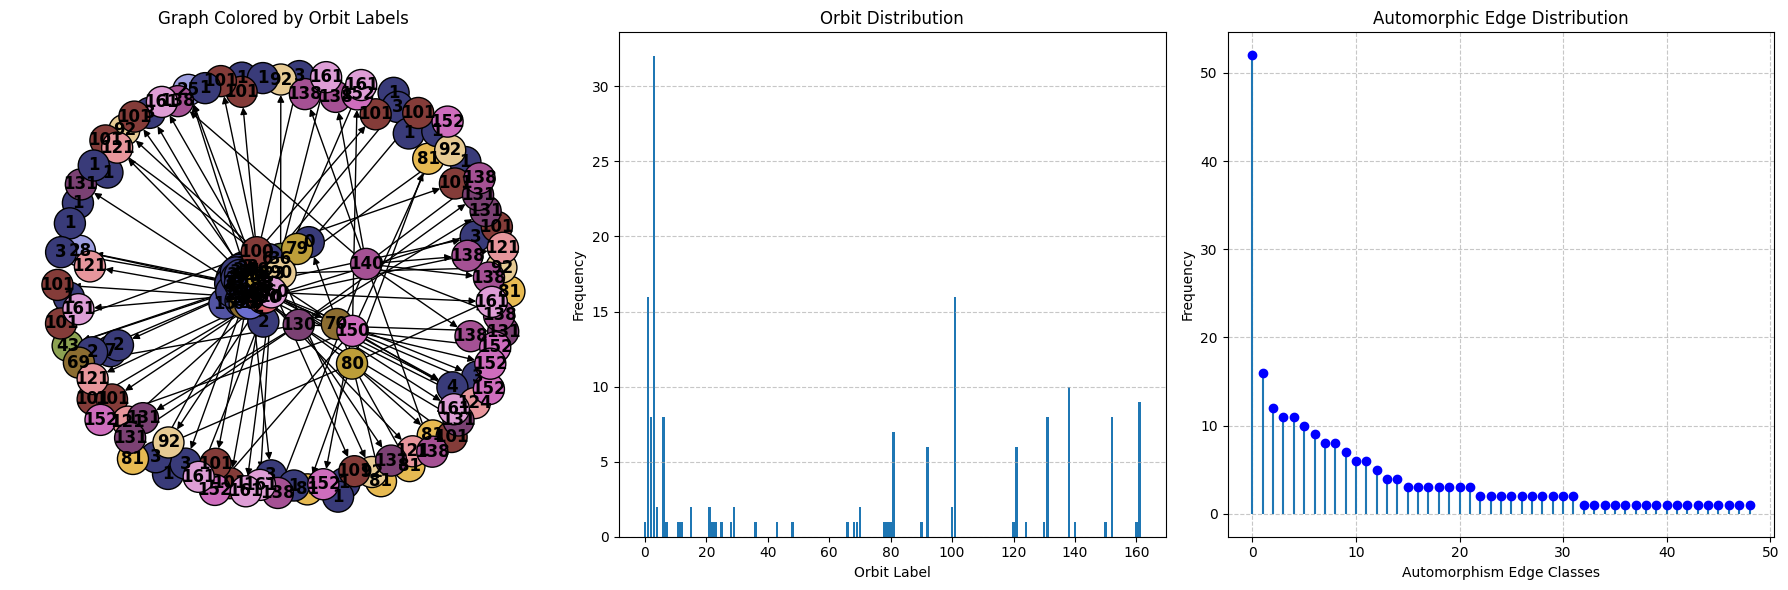

Intra-orbit edges: 2083, Inter-orbit edges: 29476
Non-distinguishable edges: 31559


<Figure size 640x480 with 0 Axes>

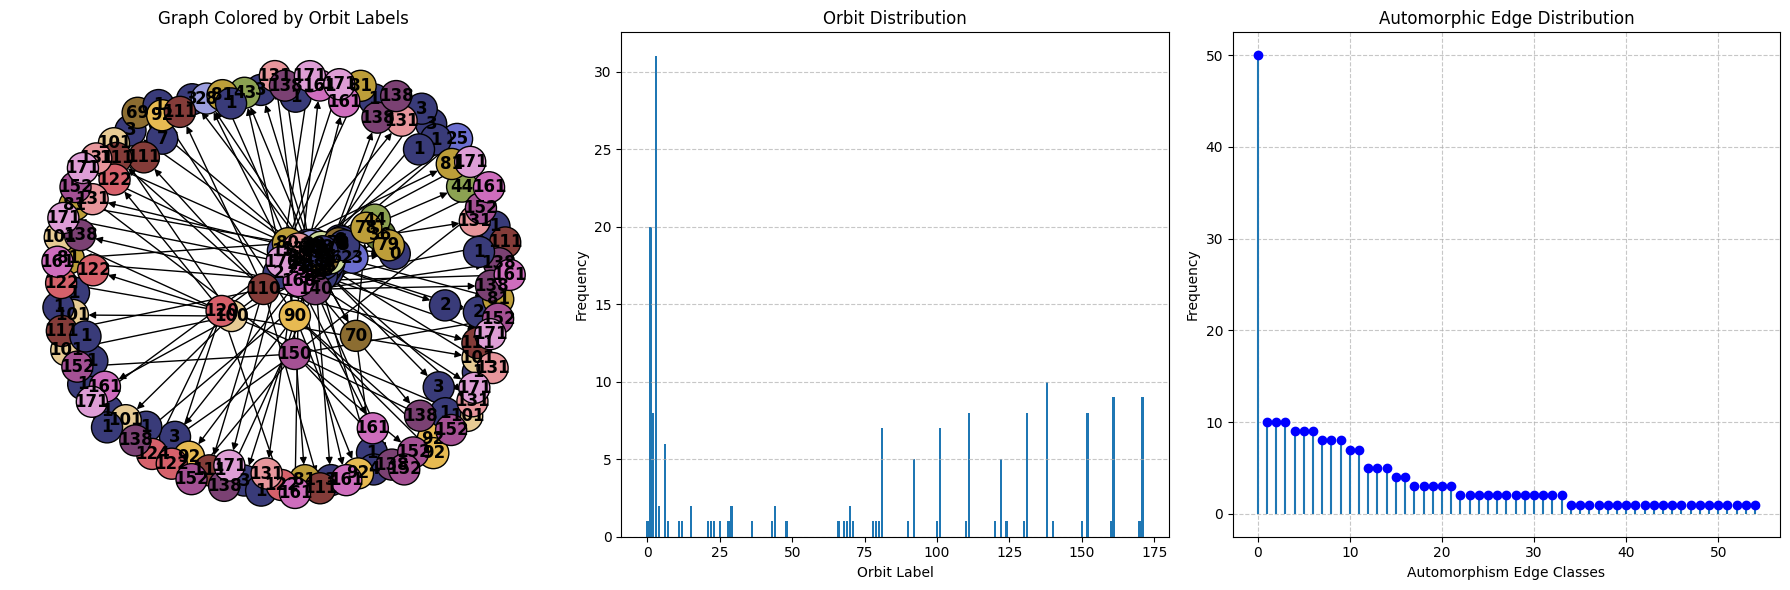

<Figure size 640x480 with 0 Axes>

In [10]:
G_data = to_networkx(data)
N = 10
for i in range(1, 100, 10):
    ig = random.choice(list(G_data.nodes))
    G_data, pyg_data, star_edges = attach_star_graph(G_data, N, ig)
    G_data = remove_random_edges(G_data, num_edges=N - 1, protected_edges=star_edges)
    pyg_data = from_networkx(G_data)
    analyze_automorphisms(pyg_data, G_data)
